In [1]:
import sys
import numpy as np
import torch 
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload

import h5py

from tqdm import tqdm
import pandas as pd

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='white', context='notebook', rc={'figure.figsize':(6,6)}, font_scale=1.5)

2.3.0+cu121
12.1
Tesla V100-PCIE-16GB
2.3.0+cu121
12.1
Tesla V100-PCIE-16GB


In [2]:
# Append this directory to sys.path
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/')
import load_cluster_data as llc 

# Append also simulation directory
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/")
import simulate_counts as sim 
reload (sim)

sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/visualization/")
import vis as vis

### Settings

In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


### Load simulated junction and intron cluster counts

In [5]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [6]:
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['Cluster_Counts'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [7]:
sim_data = final_data.copy()

In [8]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

# remake junction counts and cluster counts sp.coo_matrix for masking analysis
indices = (sim_data.cell_id_index, sim_data.junction_id_index)
junc_counts = sp.coo_matrix((sim_data.junc_count, indices))
cluster_counts = sp.coo_matrix((sim_data.Cluster_Counts, indices))

### Run full model

In [9]:
full_y_tensor

tensor(indices=tensor([[    0,   182,   970,  ...,  2401,  2377,  2371],
                       [   12,    12,    12,  ..., 46911, 46912, 46912]]),
       values=tensor([ 19.,   4.,   4.,  ...,   7.,   7., 293.]),
       size=(2405, 46913), nnz=6230006, layout=torch.sparse_coo)

In [10]:
full_total_counts_tensor

tensor(indices=tensor([[    0,   182,   970,  ...,  2401,  2377,  2371],
                       [   12,    12,    12,  ..., 46911, 46912, 46912]]),
       values=tensor([ 24.,   4.,   6.,  ...,   7.,   7., 357.]),
       size=(2405, 46913), nnz=6230006, layout=torch.sparse_coo)

/gpfs/commons/home/kisaev/Leaflet-private/src/visualization/vis.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_data_junc["cell_type"] = simple_data_junc["cell_type"].map(cell_type_map)
/gpfs/commons/home/kisaev/Leaflet-private/src/visualization/vis.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_data_junc["cell_type"] = simple_data_junc["cell_type"].astype(str)
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plot

68151
cell_type
1    925
2    832
Name: count, dtype: int64


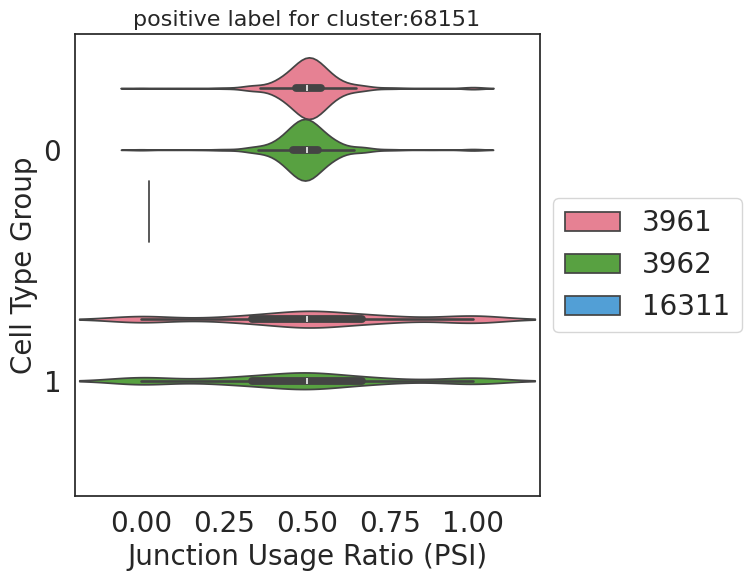

In [11]:
# let's visualize junction usage ratios for a given custer 
# sample clust from simple_data.Cluster.unique()
clust = np.random.choice(simple_data.Cluster.unique())
print(clust)
#sim.quick_clust_plot(clust, simple_data)
vis.get_clust_plot(clust, simple_data)

In [12]:
# ensure we are using gpu!
device

device(type='cuda')

In [13]:
reload(factor_model)
best_K = 2
K = best_K
print(K) 

#input_conc = 50
# set input_conc to inf
input_conc = float('inf')
plot_bb=False
#input_conc = None
all_results, variable_sizes = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=3, use_global_prior=True, K=K, lr=0.1, input_conc_prior=input_conc, loss_plot=False, num_epochs=100, save_to_file = False)

Using a fixed probability of success across all trials (infinite concentration parameter) with a binomial distribution.
Using prior for a and b per junction to model average behaviour!


2.3.0+cu121
12.1
Tesla V100-PCIE-16GB
2
Random seeds: [1097, 2945, 8577, 864, 6522]
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 1097
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 217583510.06897005
Epoch 25, Elbo loss: 84090905.8817743
Epoch 50, Elbo loss: 50349520.68657638
Epoch 75, Elbo loss: 35702348.367713295


Elbo loss: 27727627.536154315


Sample from the guide (posterior)
Calculate summary statistics
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 2 with seed 2945
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 218676639.29080808
Epoch 25, Elbo loss: 81758387.0016489
Epoch 50, Elbo loss: 46083327.62771572
Epoch 75, Elbo loss: 32723209.475164115


Elbo loss: 26446268.730152942


...

Sample from the guide (posterior)
Calculate summary statistics
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 4 with seed 864
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 225654143.0596742
Epoch 25, Elbo loss: 87570372.51843934
Epoch 50, Elbo loss: 50376855.91463566
Epoch 75, Elbo loss: 35027198.59403891


Elbo loss: 28169641.55599855


Sample from the guide (posterior)
Calculate summary statistics
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 5 with seed 6522
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 213905197.39389277
Epoch 25, Elbo loss: 80181797.90521505
Epoch 50, Elbo loss: 48193890.002550766
Epoch 75, Elbo loss: 35366927.20331573


Elbo loss: 29479121.838334847


Sample from the guide (posterior)
Calculate summary statistics
All initializations complete. Returning results.
------------------------------------------------
------------------------------------------------
Model variable sizes: {'a': torch.Size([46913]), 'b': torch.Size([46913]), 'psi': torch.Size([2, 46913]), 'pi': torch.Size([2]), 'dir_conc': torch.Size([]), 'assign': torch.Size([2405, 2])}
------------------------------------------------


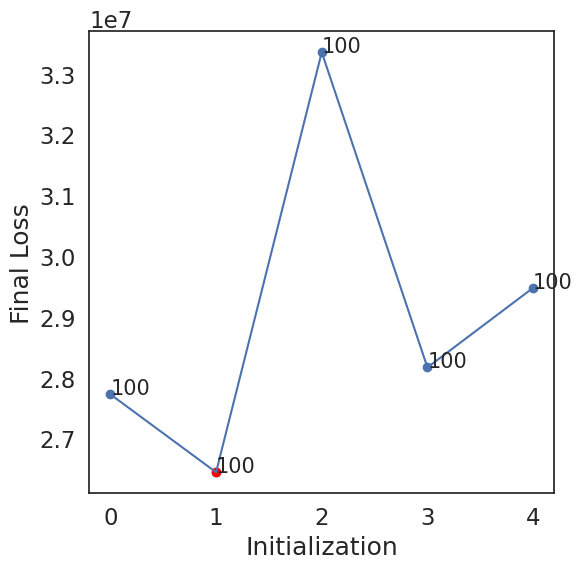

In [14]:
# figure out which index in all_results has the lowest final loss
losses = [result["losses"][-1] for result in all_results]
# get number of epochs for each initialization
num_epochs = [len(result["losses"]) for result in all_results]

# make a quick plot of the losses
plt.plot(losses)
plt.xlabel("Initialization")
plt.ylabel("Final Loss")
# make each loss value with a dot 
plt.scatter(range(len(losses)), losses)
# also mark the number of epochs
for i in range(len(losses)):
    plt.text(i, losses[i], str(num_epochs[i]), size="small")
# mark the lowest loss red
plt.scatter(np.argmin(losses), np.min(losses), color="red")

In [15]:
# Let's get assign matrix for each initialization
assign_matrices = [result["summary_stats"]["assign"]["mean"] for result in all_results]
len(assign_matrices)

5

In [16]:
# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking
from masking import *
import cost_correlation_assign
from cost_correlation_assign import *

# import reload 
from importlib import reload
reload(masking)

# double check again how i am doing this 
corrs, matchings = compare_assignments(assign_matrices)

Initialization 1 vs Initialization 2: Matched pairs [(0, 1), (1, 0)]
Initialization 1 vs Initialization 3: Matched pairs [(0, 1), (1, 0)]
Initialization 1 vs Initialization 4: Matched pairs [(0, 1), (1, 0)]
Initialization 1 vs Initialization 5: Matched pairs [(0, 0), (1, 1)]
Initialization 2 vs Initialization 3: Matched pairs [(0, 1), (1, 0)]
Initialization 2 vs Initialization 4: Matched pairs [(0, 1), (1, 0)]
Initialization 2 vs Initialization 5: Matched pairs [(0, 1), (1, 0)]
Initialization 3 vs Initialization 4: Matched pairs [(0, 0), (1, 1)]
Initialization 3 vs Initialization 5: Matched pairs [(0, 0), (1, 1)]
Initialization 4 vs Initialization 5: Matched pairs [(0, 0), (1, 1)]


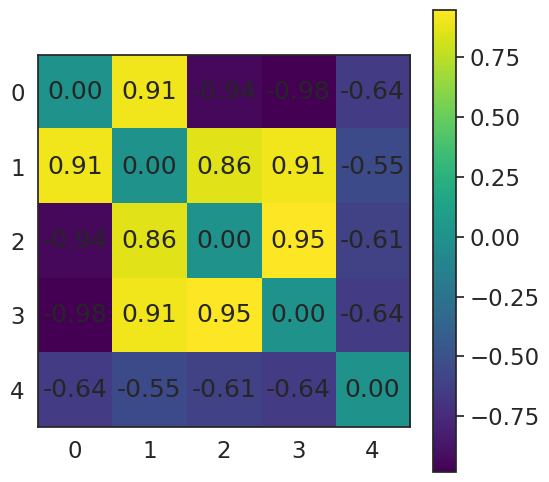

In [17]:
# plot the correlation matrix
plt.imshow(corrs, cmap="viridis")

# add colorbar
plt.colorbar()
# make the ticks show the initialization number
plt.xticks(range(len(corrs)), range(0, len(corrs)))
plt.yticks(range(len(corrs)), range(0, len(corrs)))
# print the correlation values
for i in range(len(corrs)):
    for j in range(len(corrs)):
        plt.text(i, j, f"{corrs[i, j]:.2f}", ha="center", va="center")

In [18]:
def average_pairwise_correlation(corrs):
    # Use tril_indices to access the lower triangle excluding the diagonal
    i, j = np.tril_indices_from(corrs, k=-1)
    return np.mean(corrs[i, j])

def median_pairwise_correlation(corrs):
    i, j = np.tril_indices_from(corrs, k=-1)
    return np.median(corrs[i, j])

def min_pairwise_correlation(corrs):
    i, j = np.tril_indices_from(corrs, k=-1)
    return np.min(corrs[i, j])

# Calculate the average pairwise correlation
average_corr = average_pairwise_correlation(corrs)
print(f"Average Pairwise Correlation: {average_corr}")

consistency_index = average_corr / 1.0  # Since correlation's maximum is 1
print(f"Consistency Index: {consistency_index}")

median_corr = median_pairwise_correlation(corrs)
print(f"Median Pairwise Correlation: {median_corr}")

min_corr = min_pairwise_correlation(corrs)
print(f"Minimum Pairwise Correlation: {min_corr}")

Average Pairwise Correlation: -0.07501891605921888
Consistency Index: -0.07501891605921888
Median Pairwise Correlation: -0.5811327897540839
Minimum Pairwise Correlation: -0.9832295886101861


In [19]:
# get the index of initialization with the lowest loss
best_init = np.argmin(losses)
print("The best initialization was: ", best_init)

# extract latent variables for just first seed used 
latent_vars = all_results[best_init]['summary_stats'] 

pi = latent_vars["pi"]["mean"] # overall contribution of each factor to cell population, one value per k
dir_conc = latent_vars["dir_conc"]["mean"] # one scaling value 
assign_post = latent_vars["assign"]["mean"]
psis = latent_vars["psi"]["mean"] # psi is the probability of a junction being used in a cluster
a = latent_vars["a"]["mean"] 
b = latent_vars["b"]["mean"] 
#bb_conc = latent_vars["bb_conc"]["mean"] # concentration parameter for beta-binomial distribution

print(a)
print(b)

print("The inferred concentration parameter is: " + str(dir_conc))
print("The inferred pi parameter is: " + str(pi))
#print("The inferred bb_conc parameter is: " + str(bb_conc))

The best initialization was:  1
[1.0515151  0.9454145  0.79605967 ... 1.6484462  1.7628005  1.8026546 ]
[0.62619317 1.0427629  0.890242   ... 0.96928054 0.46576142 0.57198966]
The inferred concentration parameter is: 323.00192
The inferred pi parameter is: [0.54181343 0.45818657]


In [20]:
# print shape of psi, we need this later for the extraction of mus and variances from variational params from guide 
print(psis.shape)

(2, 46913)


In [21]:
sim_data

,cell_id_index,junction_id_index,junc_count,junction_id,Cluster,Cluster_Counts,clustminjunc,juncratio,cell_id,cell_type,gene_id,new_junction_id_index,new_junc_count,new_cell_type
0,0,12,19,1_78692220_78694195,114,24,5,0.791667,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,Acsl3,0,8.0,1
1,182,12,4,1_78692220_78694195,114,4,0,1.000000,B18-B000168-3_57_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,Acsl3,0,3.0,0
2,970,12,4,1_78692220_78694195,114,6,2,0.666667,G7-B002433-3_38_F-1-1_Mammary_Gland_endothelia...,Mammary_Gland_endothelial_cell,Acsl3,0,4.0,0
3,1964,12,23,1_78692220_78694195,114,50,27,0.460000,N14-B002433-3_38_F-1-1_Mammary_Gland_luminal_e...,Mammary_Gland_luminal_epithelial_cell_of_mamma...,Acsl3,0,22.0,0
4,645,12,3,1_78692220_78694195,114,6,3,0.500000,E4-B002433-3_38_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,Acsl3,0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6230001,2381,46910,11,4_108328290_108338122,23116,13,2,0.846154,P6-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,2010305A19Rik,19461,13.0,1
6230002,2370,46911,3,X_74317703_74318367,118988,3,0,1.000000,P4-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,Fam50a,19462,0.0,0
6230003,2401,46911,7,X_74317703_74318367,118988,7,0,1.000000,P9-B002433-3_38_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,Fam50a,19462,1.0,0
6230004,2377,46912,7,11_6349493_6350605,75653,7,0,1.000000,P5-B002438-3_38_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,Ogdh,19463,0.0,1


In [22]:
cell_types_id = sim_data[["cell_id", "cell_id_index", "cell_type"]].drop_duplicates()
# reorder by cell_id_index
cell_types_id = cell_types_id.sort_values(by = ["cell_id_index"])
cell_types_id.head()

,cell_id,cell_id_index,cell_type
0,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,0,Mammary_Gland_basal_cell
1814,A10-B000166-3_56_F-1-1_Mammary_Gland_basal_cell,1,Mammary_Gland_basal_cell
178,A10-B002433-3_38_F-1-1_Mammary_Gland_basal_cell,2,Mammary_Gland_basal_cell
248,A10-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,3,Mammary_Gland_basal_cell
2320,A10-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,4,Mammary_Gland_basal_cell


In [23]:
cell_types_id.cell_type.value_counts()

cell_type
Mammary_Gland_basal_cell                                  1340
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland     578
Mammary_Gland_stromal_cell                                 440
Mammary_Gland_endothelial_cell                              47
Name: count, dtype: int64

In [24]:
assign_post_df = pd.DataFrame(assign_post)

In [25]:
# print pyro params guide variables 
print("The pyro params guide variables are: ")
pyro.get_param_store().keys()

# get length of params in each key of param store
for key in pyro.get_param_store().keys():
    print(key, len(pyro.get_param_store()[key]))

The pyro params guide variables are: 


dict_keys(['AutoGuideList.0.loc', 'AutoGuideList.0.scale', 'AutoGuideList.1.loc', 'AutoGuideList.1.scale', 'AutoGuideList.2.loc', 'AutoGuideList.2.scale'])

In [28]:
J = psis.shape[1]
print(K * J)

# Let's extract the values in .0.loc and .0.scale for each key in param store 
psis_mus = pyro.get_param_store()["AutoGuideList.0.loc"]
psis_loc = pyro.get_param_store()["AutoGuideList.0.scale"]

# reshape psis_mus and psis_loc to be K x J
psis_mus = psis_mus.reshape(K, J)
psis_loc = psis_loc.reshape(K, J)

# get the shape of psis_mus
psis_mus.shape, psis_loc.shape

(torch.Size([2, 46913]), torch.Size([2, 46913]))

In [29]:
J = psis.shape[1]
jj = np.random.randint(J)
jj = 163
from scipy.stats import beta

if plot_bb:

    # Generate values for the x-axis
    x = np.linspace(0, 1, 1000)

    success_probs = psis[:,jj]
    bbconc_param = bb_conc
    print(f"The bb conc param is {bbconc_param}")
    conc_params = [10, bbconc_param, 1000]
    fig, axs = plt.subplots(1, 4, figsize=(15, 5))
    # Define a single legend for all curves
    legend_labels = []

    for i, conc_param in enumerate(conc_params):

        # Plot individual curves for each success probability
        for j, success_prob in enumerate(success_probs):
            # Calculate shape parameters for the Beta distribution
            bb_alpha = success_prob * conc_param
            bb_beta = (1 - success_prob) * conc_param

            # Calculate the probability density function (PDF) of the beta distribution
            pdf = beta.pdf(x, bb_alpha, bb_beta)

            # Plot the Beta distribution
            # axs[i].plot(x, pdf, label=f'Success Prob {j+1}: {success_prob:.2f}')
            # Plot the Beta distribution and store the label for the legend
            line, = axs[i].plot(x, pdf, label=f'Success Prob {jj+1}: {success_prob:.2f}')
            if i == 0:  # Add legend labels only once
                legend_labels.append(line.get_label())
            
        axs[i].set_title(f'Beta Distribution (Cell State: {conc_param})', fontsize=10)
        axs[i].set_xlabel('x')
        axs[i].set_ylabel('Probability Density')
        axs[i].grid(True)

    # Also plot the Beta distribution average junction behaviour using a_j and b_j values
    # in this case just a[1] and b[1] for the current junction 
    bb_alpha = a[jj]
    bb_beta = b[jj]
    bb_avg = bb_alpha / (bb_alpha+bb_beta)
    print(f"The average junction behaviour is: {bb_avg:.2f}")
    pdf = beta.pdf(x, bb_alpha, bb_beta)
    axs[3].plot(x, pdf, label=f'Average Junction Behaviour')
    axs[3].set_title('Beta Distribution (Average Junction Behaviour)', fontsize=10)
    axs[3].set_xlabel('x')
    axs[3].set_ylabel('Probability Density')
    axs[3].grid(True)
    
    # extract only unique values from legend lines 
    fig.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    # print the plot
    # print axs[2]

    plt.show()

In [30]:
psis_mus.shape

torch.Size([2, 46913])

In [31]:
j = np.random.randint(J)

# let's do a sanity check that the mus and scales of PSIs would correspond to what we sample from the beta distribution posterior
# sample j from J 
print(f"Junction {j}")

# get mu_j and scale_j for junction j from variational params
mu_j = psis_mus[:,j]
scale_j = psis_loc[:,j]

print(f"Mean of PSIs: {mu_j}")
print(f"Scale of PSIs: {scale_j}")

# for each mu_kj and scale_kj we sample from a normal distribution with mean mu_kj and scale scale_kj
# use torch normal distirbution to sample one value for each k 

# sample from normal distribution, one value for each k
sampled_vals = torch.normal(mu_j, scale_j)

# calculate sigmoid of each value using torch 
sigmoid_vals = torch.sigmoid(sampled_vals)
sigmoid_vals

Junction 44950
Mean of PSIs: tensor([ 0.2818, -0.6150], grad_fn=<SelectBackward0>)
Scale of PSIs: tensor([2.1685, 1.8084], grad_fn=<SelectBackward0>)


tensor([0.8938, 0.7856], grad_fn=<SigmoidBackward0>)

In [32]:
psis[:,j] # sometimes the order of K in the psis and sigmoid vals seems to be switched?!

array([0.5410531, 0.4778934], dtype=float32)

In [33]:
# initiate new tensor to store the sigmoid values 
psis_variational = torch.zeros(K, J)

# collect all the sigmoids values for each junction k 
for j in range(J):
    mu_j = psis_mus[:,j]
    scale_j = psis_loc[:,j]
    sampled_vals = torch.normal(mu_j, scale_j)
    sigmoid_vals = torch.sigmoid(sampled_vals)
    psis_variational[:,j] = sigmoid_vals

In [34]:
psis_torch = torch.tensor(psis)
# compare psis and psis_variational
print("The correlation between the true PSIs and the variational PSIs is: ")
correlation = torch.nn.functional.cosine_similarity(psis_variational, psis_torch, dim=1)
correlation

The correlation between the true PSIs and the variational PSIs is: 


tensor([0.8811, 0.8767], grad_fn=<SumBackward1>)

### Evaluate latent factor space

In [35]:
# make UMAP using average assign_post across seeds and color points by cell_type 
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# run UMAP on assign_post matrix
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post)

In [36]:
cell_ids_conversion = sim_data[["cell_id", "cell_id_index", "cell_type"]].drop_duplicates()

In [37]:
sim_data.columns

Index(['cell_id_index', 'junction_id_index', 'junc_count', 'junction_id',
       'Cluster', 'Cluster_Counts', 'clustminjunc', 'juncratio', 'cell_id',
       'cell_type', 'gene_id', 'new_junction_id_index', 'new_junc_count',
       'new_cell_type'],
      dtype='object')

In [38]:
junction_ids_conversion = sim_data[["Cluster", "junction_id", "junction_id_index", "gene_id"]].drop_duplicates()

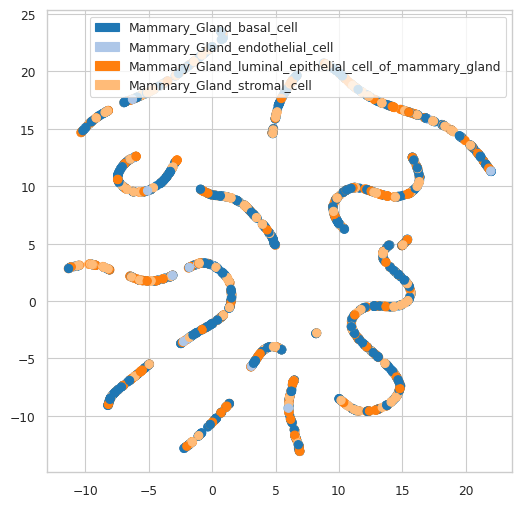

In [39]:
sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(6, 6))

cell_types = cell_ids_conversion.cell_type

cell_types_unique = cell_types.unique()
cell_type_colors = sns.color_palette("tab20", len(cell_types_unique))
cell_type_dict = dict(zip(cell_types_unique, cell_type_colors))
cell_colors = cell_types.map(cell_type_dict)

# Plot the UMAP embedding
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=35, c=cell_colors
)

# Create legend handles and labels
legend_handles = [mpatches.Patch(color=color, label=cell_type) for cell_type, color in cell_type_dict.items()]

# Add legend to the plot
plt.legend(handles=legend_handles)

In [40]:
assign_post

array([[0.52421117, 0.47578883],
       [0.53745925, 0.46254072],
       [0.55171156, 0.44828847],
       ...,
       [0.5711187 , 0.4288813 ],
       [0.53873587, 0.4612642 ],
       [0.56748956, 0.43251047]], dtype=float32)

Text(0, 0.5, 'Factor 2')

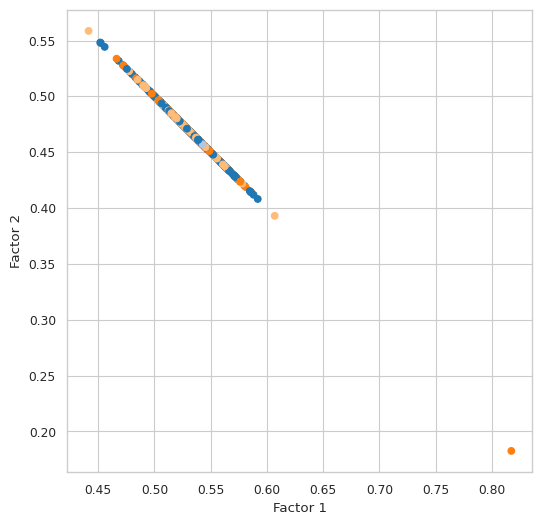

In [41]:
# make simple scatter plot of assign_post matrix
plt.figure(figsize=(6, 6))
plt.scatter(assign_post[:,0], assign_post[:,1], c=cell_colors)
plt.xlabel("Factor 1")
plt.ylabel("Factor 2")

         pi    Factor
0  0.541813  Facotor0
1  0.458187  Facotor1


/scratch/ipykernel_36722/415432497.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")


Text(0.5, 1.0, 'Overall contribution of each factor to cell population')

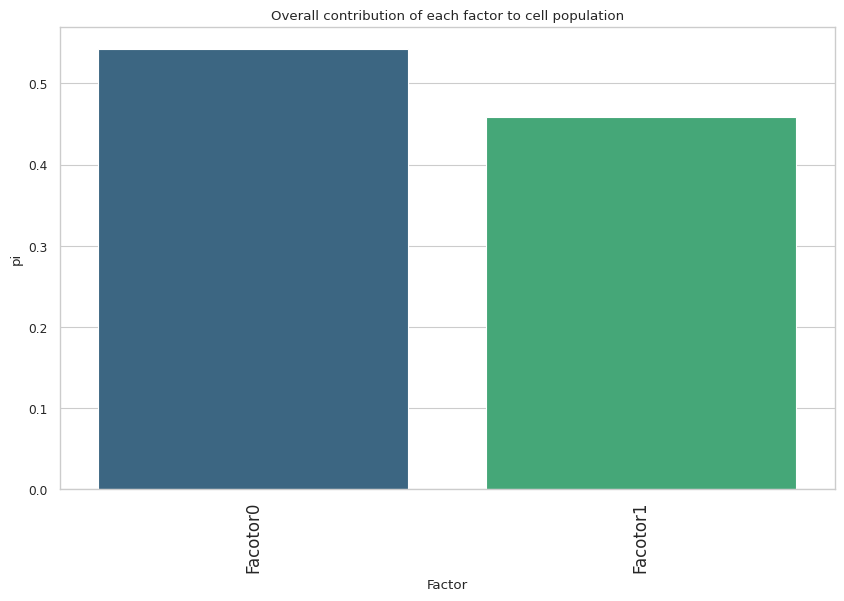

In [42]:
# make sorted barplot of pi
pi_df = pd.DataFrame(pi, columns=["pi"])
# add factor number column 
pi_df["Factor"] = "Facotor"+pi_df.index.astype(str)
pi_df = pi_df.sort_values(by="pi", ascending=False)
print(pi_df.head())

# make barplot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")
ax.set_xlabel("Factor")
# rotate x labels 90 degres 
plt.xticks(rotation=90, size=12)

ax.set_ylabel("pi")
ax.set_title("Overall contribution of each factor to cell population")

In [43]:
# convert into a data frame
psi_df = pd.DataFrame(psis)

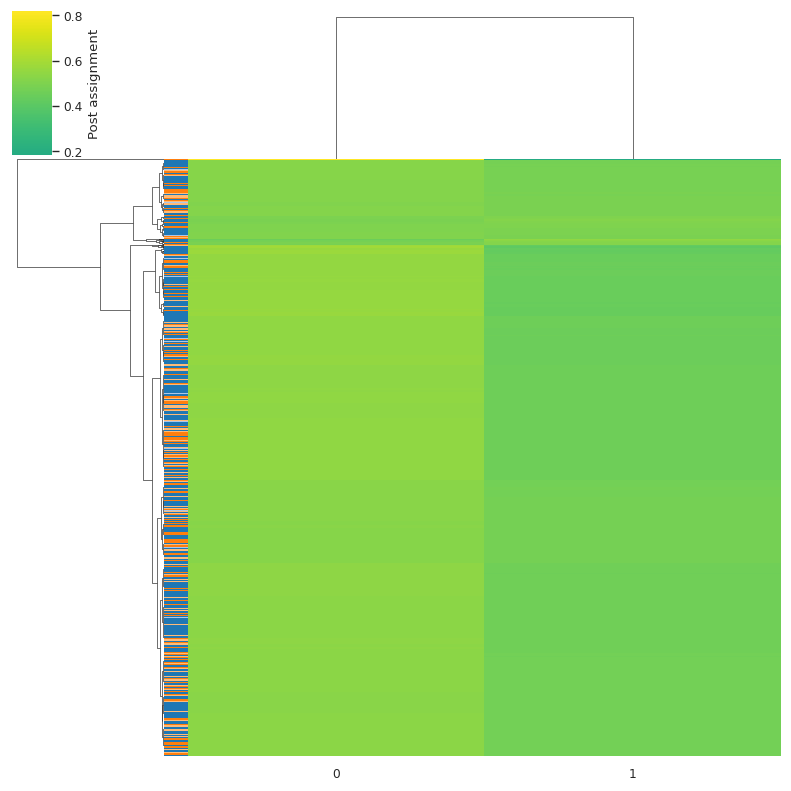

In [44]:
# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type'].unique()
num_unique_types = len(unique_cell_types)
# Get collors 
colors = sns.color_palette("tab20", num_unique_types)

# Create a dictionary mapping cell types to colors
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}

# Get cell type labels for each cell
cell_types = cell_ids_conversion.cell_type.values

# Create a list of colors for each cell based on its cell type
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

# Use the custom color palette in your clustermap
cluster = sns.clustermap(
    data=assign_post,
    method='complete',
    cmap="viridis",
    annot=False,
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Post assignment'} 
)

In [45]:
# Now let's implement ALBF so can see which junctions are selected to be differentially spliced and then see if this corresponds to the true labels that were simulated
# load ALBF code from differential_splicing.py
import differential_splicing
reload(differential_splicing)

<module 'differential_splicing' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/differential_splicing.py'>

In [46]:
junction_ids_conversion[junction_ids_conversion["new_junction_id_index"] == 18332]

KeyError: 'new_junction_id_index'

In [ ]:
clust = np.random.choice(simple_data.Cluster.unique())
print(clust)
#sim.quick_clust_plot(clust, simple_data)
vis.get_clust_plot(71638, simple_data)

In [ ]:
def plot_logit_normal_distribution_with_samples(psis_mus, psis_loc, psis, j):

    """
    Plot the logit-normal distributions for each row using the mean and standard deviation provided for a specific column index j.

    :param psis_mus: Tensor of shape (2, N), means of the logit-normal distributions
    :param psis_loc: Tensor of shape (2, N), standard deviations of the logit-normal distributions
    :param j: Column index to select the mean and standard deviation
    """
    psis_mus = psis_mus.cpu().detach().numpy()  # Convert tensors to numpy arrays
    psis_loc = psis_loc.cpu().detach().numpy()
    
    # Extract the means and standard deviations for the specific column j
    means = psis_mus[:, j]
    std_devs = psis_loc[:, j]
    psi_samples_final = psis[:, j]

    # Create a plot
    plt.figure()

    for mean, std_dev, final_sample in zip(means, std_devs, psi_samples_final):
        # Sample values from the normal distribution of y
        y_samples = np.random.normal(mean, std_dev, 10000)
        # Transform y to psi
        psi_samples = 1 / (1 + np.exp(-y_samples))

        # Plot the histogram of the psi samples to show the distribution
        plt.hist(psi_samples, bins=100, density=True, alpha=0.6, label=f'Logit-Normal Dist (mean={mean}, std={std_dev})')

        # Plot the final sampled values of psi as a line
        plt.axvline(final_sample, color='grey', linestyle='--', linewidth=1, label=f'Sampled Value (psi={final_sample})')
        plt.xlim(0, 1)

    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.title('Logit-Normal Distributions for Psi with Sampled Values')
    plt.grid(True)
    plt.show()

In [ ]:
plot_logit_normal_distribution_with_samples(psis_mus, psis_loc, psis, 18332)

In [ ]:
import torch

def combined_mean_variance(means, variances):
    eps = 1e-10  # Small value to ensure numerical stability
    variances = torch.clamp(variances, min=eps)
    inv_variances = 1 / variances
    combined_variance = 1 / torch.sum(inv_variances, dim=0)
    combined_mean = combined_variance * torch.sum(means * inv_variances, dim=0)
    return combined_mean, combined_variance

def gaussian_pdf(x, mean, std):
    eps = 1e-10  # Small value to ensure numerical stability
    var = std ** 2 + eps
    denom = (2 * torch.pi * var) ** 0.5
    num = torch.exp(- (x - mean) ** 2 / (2 * var))
    return num / denom

def check_for_nan_inf(tensor, name):
    if torch.isnan(tensor).any():
        print(f"{name} contains NaN values")
    if torch.isinf(tensor).any():
        print(f"{name} contains infinity values")

def likelihood_under_null(means, variances):
    eps = 1e-10  # Small value to ensure numerical stability
    combined_mean, combined_variance = combined_mean_variance(means, variances)
    combined_std = combined_variance ** 0.5

    # Calculate the combined Gaussian PDF at zero
    combined_pdf_zero = gaussian_pdf(torch.tensor(0.0), combined_mean, combined_std)
    combined_pdf_zero = torch.clamp(combined_pdf_zero, min=eps)
    
    # Calculate the product of Gaussian PDFs evaluated at zero for each mean and std
    # DO SUM OF LOGS INSTEAD!
    product_pdfs_zero = torch.prod(gaussian_pdf(torch.tensor(0.0), means, variances ** 0.5), dim=0)
    product_pdfs_zero = torch.clamp(product_pdfs_zero, min=eps)
    
    # Compute the full likelihood under null hypothesis
    likelihood_H0 = product_pdfs_zero / combined_pdf_zero
    
    # Debugging prints
    print("Combined Mean:", combined_mean)
    print("Combined Variance:", combined_variance)
    print("Combined PDF Zero:", combined_pdf_zero)
    print("Product PDFs Zero:", product_pdfs_zero)
    print("Likelihood H0:", likelihood_H0)
    
    # Check for NaN or infinity values
    check_for_nan_inf(combined_mean, "Combined Mean")
    check_for_nan_inf(combined_variance, "Combined Variance")
    check_for_nan_inf(combined_pdf_zero, "Combined PDF Zero")
    check_for_nan_inf(product_pdfs_zero, "Product PDFs Zero")
    check_for_nan_inf(likelihood_H0, "Likelihood H0")
    
    return likelihood_H0

def compute_albf(psis, psis_mus, psis_loc):
    # Compute likelihood under H_0 for each junction
    likelihood_H0 = likelihood_under_null(psis_mus, psis_loc)

    # Compute ALBF for each junction
    albf = -torch.log(likelihood_H0)
    
    # Convert -0.0 to 0
    albf = torch.where(albf == -0.0, torch.tensor(0.0), albf)
    return albf, likelihood_H0

In [ ]:
albf, l0 = compute_albf(psis, psis_mus, psis_loc+0.0001)
l0 = l0.detach().cpu()
albf = albf.detach().cpu()
albf_df = pd.DataFrame(albf, columns=["ALBF"])
albf_df["new_junction_id_index"] = range(albf_df.shape[0])
albf_df.iloc[7898]

In [ ]:
albf_df.sort_values(by="ALBF", ascending=False)

In [ ]:
sns.histplot(albf.detach().cpu())

In [ ]:
# turn psis into df and merge with combined_df give new junction_id_index column first 
psis_df = pd.DataFrame(psis.T)
psis_df["new_junction_id_index"] = psis_df.index
psis_df = psis_df.merge(albf_df, on = ["new_junction_id_index"])

# add difference column 1-0 
psis_df["difference"] = psis_df[1] - psis_df[0]
psis_df["difference"] = np.abs(psis_df["difference"])
psis_df.head()

In [ ]:
# plot ALBF vs difference
plt.figure(figsize=(5,5))
sns.scatterplot(data = psis_df, x = "difference", y = "ALBF")
# calcualte spearman correlation between ALBF and difference
correlation = psis_df["ALBF"].corr(psis_df["difference"], method="spearman")
print(correlation)

In [ ]:
cell_type_psi_df = cell_type_psi_df.merge(albf_df, on = ["new_junction_id_index"])

In [ ]:
# make density plot of ALBF vlaues and color by true_label
plt.figure(figsize=(6, 6))
sns.kdeplot(data=cell_type_psi_df, x="ALBF", hue="true_label", fill=True)
plt.xlabel("ALBF")


In [ ]:
cell_type_psi_df.ALBF.min()

In [ ]:
subdat = cell_type_psi_df[cell_type_psi_df["true_label"] == "positive"].sort_values(by="ALBF", ascending=True)
plt.figure(figsize=(6, 6))
sns.kdeplot(data=subdat, x="ALBF", hue="true_label", fill=True)
plt.xlabel("ALBF")

In [ ]:
cell_type_psi_df.sort_values("ALBF")

In [ ]:
psis[:, 631], psis_variational[:, 631]

In [ ]:
vis.get_clust_plot(51233, simple_data)